In [1]:
import numpy as np
import pandas as pd

import time
import warnings
import os
import sys

warnings.filterwarnings("ignore")
sys.stderr = open(os.devnull, 'w')

## Contents
1. **Time-Series Data Exploration** <br> _Time-Series plot<br>Time-Series decomposition_
2. **Models and Parameters identification** <br>_SARIMA Fine-tuning<br>Kats metalearning_
3. **Machine Learning setup** <br> _Datasets<br>Methods and Models_
4. **Training and Forecasting** <br> _Direct 60-day forecasting (fh=60)<br>Rolling 1-day forecasting (fh=1)_
5. **Models Comparison** <br>_Performance Summarization._

# 1) Time-Series Data Exploration

In [2]:
ts = pd.read_csv('/home/petewojtczak/datasets_csv/date_count.csv')
ts

,Date,count
0,2012-08-25,3
1,2012-08-26,3
2,2012-08-27,2
3,2012-08-28,2
4,2012-08-29,2
...,...,...
573,2014-03-21,149
574,2014-03-22,129
575,2014-03-23,119
576,2014-03-24,214


In [3]:
# basic info
print(f'Number of rows: {ts.shape[0]}')
print(f'Number of columns: {ts.shape[1]}')
print(f'Data types: {set(ts.dtypes.values)}')
print(f'Missing values: {ts.isnull().values.any()}')
print(f"Duplicates: {ts.duplicated().sum()}")

Number of rows: 578
Number of columns: 2
Data types: {dtype('int64'), dtype('O')}
Missing values: False
Duplicates: 0


In [4]:
# descriptive statistics
ts['count'].describe().to_frame().T

,count,mean,std,min,25%,50%,75%,max
count,578.0,78.181661,71.418652,2.0,17.0,52.0,127.75,299.0


## Time-Series plot

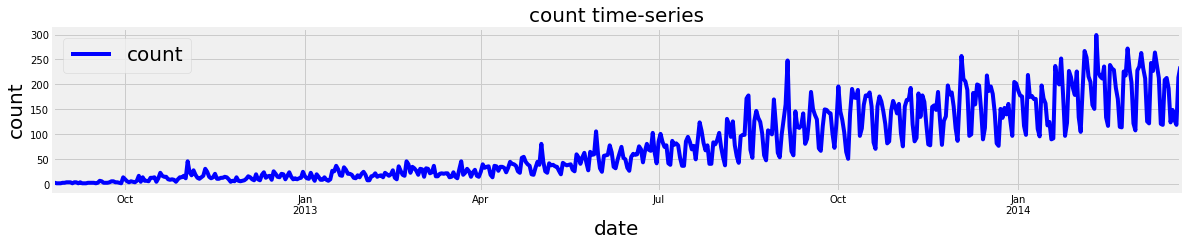

In [5]:
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
%matplotlib inline

# some essential preprocessing for plotting
ts['Date'] = pd.to_datetime(ts['Date'])
ts.set_index('Date', inplace=True)

ts.plot(color='blue')
plt.title('count time-series', size=20)
plt.xlabel('date', size=20)
plt.ylabel('count', size = 20)
plt.gcf().set_size_inches(18, 3)
plt.legend(loc=2, prop={'size': 20})
plt.show()

## Time-Series decomposition

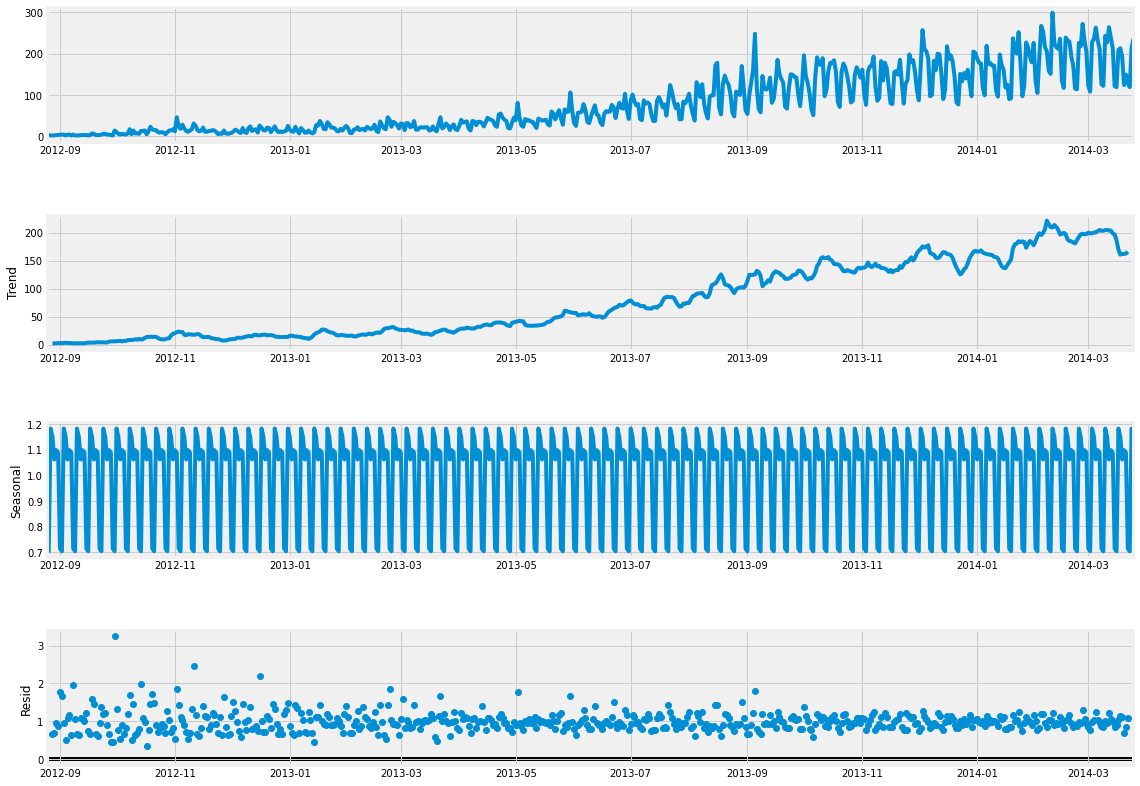

In [6]:
from statsmodels.tsa.seasonal import seasonal_decompose

decompose = seasonal_decompose(ts, model='multiplicative')
decompose.plot()
plt.gcf().set_size_inches(18, 12)
plt.show()

Let's have a closer look at the seasonality.

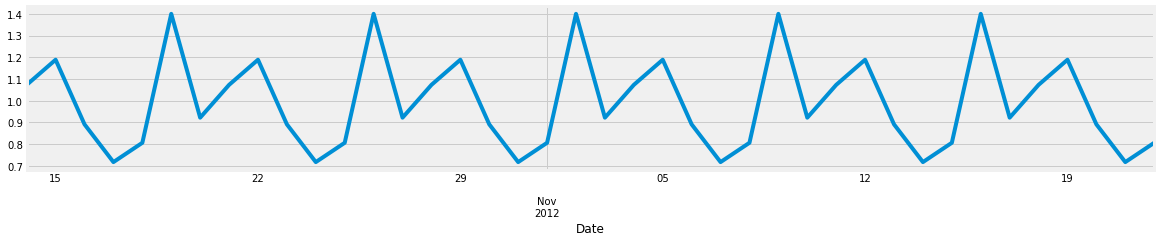

In [7]:
magified_seasonality = ts.iloc[50:90]
magified_seasonality.asfreq('D')

decomp = seasonal_decompose(magified_seasonality, model='multiplicative')
decomp.seasonal.plot()

plt.gcf().set_size_inches(18, 3)
plt.show()

It is now evident that `weekly seasonality` is present.

# 2) Models and Parameters identification
First, let's mention SARIMA. Since it might be worthwhile, some time is dedicated to fine-tuning the parameters of this renowned classic. Additionally, we would like to venture off the beaten path and employ an AutoML solution by Kats, specifically metalearning. This approach features well-ranged, randomized defaults that promise to comprehensively search the parameter spaces of specified models.

## SARIMA Fine-tuning

In [8]:
import statsmodels.api as sm
import statsmodels.tsa.api as smt

# adopted from https://www.kaggle.com/kashnitsky/topic-9-part-1-time-series-analysis-in-python?scriptVersionId=50985180&cellId=80
def tsplot(y, lags=None, figsize=(12, 7), style='bmh'):
    """
        Plot time series, its ACF and PACF, calculate Dickey–Fuller test
        
        y - timeseries
        lags - how many lags to include in ACF, PACF calculation
    """
    if not isinstance(y, pd.Series):
        y = pd.Series(y)        
        
    with plt.style.context(style):    
        fig = plt.figure(figsize=figsize)
        layout = (2, 2)
        ts_ax = plt.subplot2grid(layout, (0, 0), colspan=2)
        acf_ax = plt.subplot2grid(layout, (1, 0))
        pacf_ax = plt.subplot2grid(layout, (1, 1))
        
        y.plot(ax=ts_ax)
        p_value = sm.tsa.stattools.adfuller(y)[1]
        ts_ax.set_title('Time Series Analysis Plots\n Augmented Dickey-Fuller: p={0:.5f}'.format(p_value))
        smt.graphics.plot_acf(y, lags=lags, ax=acf_ax)
        smt.graphics.plot_pacf(y, lags=lags, ax=pacf_ax)
        plt.tight_layout()

In [9]:
# statistical interference will be necessary, so test data is kept intact
y_train = ts.iloc[:len(ts)-60]

### Stationarity
According to the plot, trend and heteroscedasticity seems to be obvious. Cubic root transformation is applied.

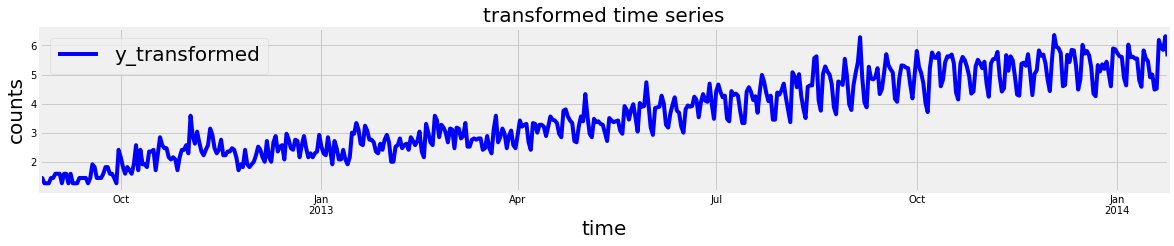

In [10]:
y_train['y_transformed'] = np.cbrt(y_train['count'])

y_train['y_transformed'].plot(color='blue')
plt.title('transformed time series', size=20)
plt.xlabel('time', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(18, 3)
plt.legend(loc=2, prop={'size': 20})
plt.show()

Heteroscedasticity appears to be pretty much gone. Trend also looks better, more linear. Let's remove it, and then have a closer look at the data.

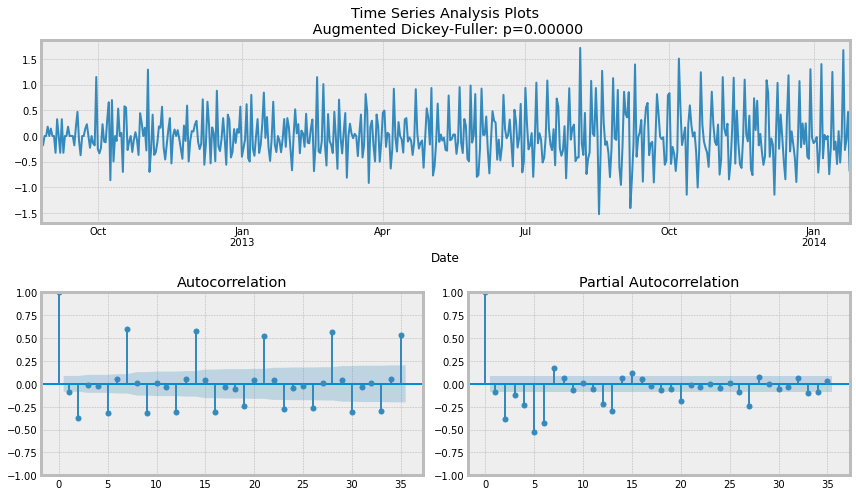

In [11]:
y_train['y_transformed_diff'] = y_train['y_transformed'] - y_train['y_transformed'].shift(1)
y_train.dropna(inplace=True)
tsplot(y_train['y_transformed_diff'], lags=35)

`ADF` indicates no unit root. `ACF` confirms weekly seasonality. This needs some attention. Hopefully, dealing with sesonality will address the slightly reappeared heteroscedasticity as well.

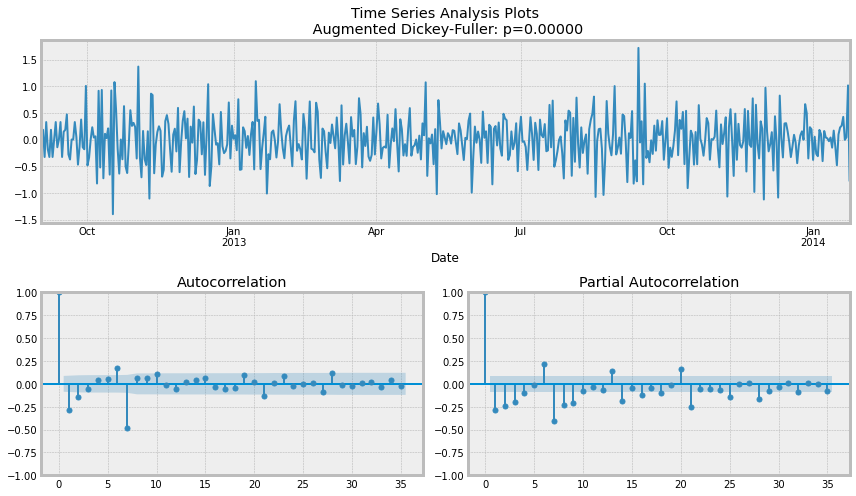

In [12]:
y_train['y_transformed_diff_sdiff'] = y_train['y_transformed_diff'] - y_train['y_transformed_diff'].shift(7)
y_train.dropna(inplace=True)
tsplot(y_train['y_transformed_diff_sdiff'], lags=35)

This is exacly what we wanted to see. Now, SARIMA parameters can finally be derived.

* `p` is most probably 3 since it is the last significant lag on the PACF, after which most others are not significant.
* `d` equals 1 because we had first differences.
* `q` should most likely be 2 as seen on the ACF.
* `P` might be 4, since the 7th lag is significant and the 14th, 21st, and 28th lags are somewhat significant on the PACF.
* `D` again equals 1 because we performed seasonal differentiation.
* `Q` is deemed to be 1. The 7th lag on ACF is significant while the 14th is not.
* `s` is, in our case, 7.


## Kats metalearning
This tool is designed to select the best-performing model and its parameters from a predefined list for a given time-series. Subsequently, this model, along with SARIMA and the other models in consideration, is then used in the proper training computation and forecasts generation (section 4).

In [13]:
from kats.consts import TimeSeriesData
from kats.consts import SearchMethodEnum
from kats.models.holtwinters import HoltWintersModel, HoltWintersParams
from kats.models.stlf import STLFModel, STLFParams
from kats.models.theta import ThetaModel, ThetaParams
from kats.models.metalearner.get_metadata import GetMetaData

# Kats expects specified format; np.cbrt() transformed data is adopted (more details on that is provided in Secion 3.1)
y_train = ts.iloc[:len(ts)-60]
y_train = np.cbrt(y_train)
y_train.reset_index(inplace=True)
y_train.columns = ["time", "value"]
y_train = TimeSeriesData(y_train)

print('Getting metadata ...')
start = time.time()

MD = GetMetaData(
    all_models={"holtwinters": HoltWintersModel,"theta": ThetaModel,"stlf": STLFModel,},
    all_params={"holtwinters": HoltWintersParams,"theta": ThetaParams,"stlf": STLFParams,},
    data=y_train,
    error_method='mae')

y_train_metadata = MD.get_meta_data()

end = time.time()
print('Metadata successfully generated. ({:.2f} s)'.format(end-start))

Getting metadata ...
Metadata successfully generated. (22.03 s)


Metalearner suggested model and its specification:

In [14]:
print(y_train_metadata['best_model'])
print(y_train_metadata['hpt_res'][y_train_metadata['best_model']])

holtwinters
({'damped': True, 'seasonal_periods': 7, 'trend': 'additive', 'seasonal': 'multiplicative'}, 0.03770569488093478)


# 3) ML Setup
In this section, we organize datasets and outline the models and methods to be employed. We explore two distinct approaches. 

`The first approach`, affiliated with Kats models here, aims to directly leverage the inherent temporal order within time-series data. 

`The second approach`, associated with sklearn and sktime, consists of models originally designed for regression tasks. However, sktime delivers `make_reduction()`, function which transforms time-series data into a tabular format, effectively reframing the forecasting task into a regression problem.

## Datasets
Given the presence of heteroscedasticity in the raw time-series data, we will apply a cube root transformation using `np.cbrt()` to the training data of all our models. Regardless of whether homoscedasticity is an explicit assumption of any particular method, employing the transformed data is advantageous. Models and its default settings are, in general, better suited to handle the type of transformed data indicated by the plots.

In [15]:
# container for training data
datasets = {}

# Metalearner, SARIMA, prophet, holtwinters share the same dataset and TimeSeriesData format
datasets['Prophet'] = y_train
datasets['holtwinters'] = y_train
datasets['SARIMA'] = y_train

# sklearn works with numpy/pandas datatypes
y_train = ts.iloc[:len(ts)-60]
y_train = np.cbrt(y_train)
datasets['ML_sklearn'] = y_train

## Methods and Models

In [16]:
from kats.models.sarima import SARIMAModel, SARIMAParams
from kats.models.prophet import ProphetModel, ProphetParams
from kats.models.holtwinters import HoltWintersModel, HoltWintersParams

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import ElasticNet
from sklearn.neighbors import KNeighborsRegressor

# approach 1: SARIMA and holtwinets params have been identified; Prophet can digest everything out of the box
params = {
    'SARIMA': SARIMAParams(p=3, d=1, q=2,  seasonal_order=(4,1,1,7)),
    'Prophet': ProphetParams(),
    'holtwinters': HoltWintersParams(trend="add", damped=True, seasonal="mul", seasonal_periods=7)}

# approach 1: models with corresponding pre-prepared datasets and params
kats_techniques = {
    'SARIMA': SARIMAModel(data=datasets['SARIMA'], params=params['SARIMA']),
    'Prophet': ProphetModel(datasets['Prophet'], params['Prophet']),
    'holtwinters': HoltWintersModel(data=datasets['holtwinters'], params=params['holtwinters'])}

# approach 2: ForecastingGridSearchCV tool will find by brute force best params for regressors
hypergrid = {
    'gbr': {
        "estimator__learning_rate":[0.001, 0.01, 0.1, 0.3, 0.5],
        "estimator__warm_start":[True, False]         },
    'enet': {
        "estimator__alpha":[0.001, 0.01, 0.1, 0.2],
        "estimator__warm_start":[True, False],
        "estimator__l1_ratio":[0.01, 0.1, 0.2, 0.3, 0.5]},
    'knn': {
        "estimator__weights":['uniform', 'distance'],
        "estimator__n_neighbors":[100 , 150]}}

# approach 2: sklearn regressors; requires data tabulation to perform forecasting
regressors = {
    'gbr': GradientBoostingRegressor(),
    'enet': ElasticNet(),
    'knn': KNeighborsRegressor()}

# 4) Training and Forecasting
This section encompasses the procedures and essential computations, involving the digestion of datasets and the generation of forecasts.

## Direct 60-day forecasting (fh=60)

In [17]:
from sktime.forecasting.base import ForecastingHorizon
from sktime.performance_metrics.forecasting import MeanAbsoluteError

# tabularization
from sktime.forecasting.compose import make_reduction
# hypertuning (for regressors)
from sktime.forecasting.model_selection import (ForecastingGridSearchCV,ExpandingWindowSplitter)

# forecasts container; here we collect direct 60-day forecasts for every model calculation
forecasts_fh60 = {}

for technique in datasets.keys():
    if technique in kats_techniques.keys():
        print('*[kats] Starting training for {}...'.format(technique))
        start = time.time()
        
        # model instantiation
        model = kats_techniques[technique]
        # model fitting; datasets and params have already been designated in section 3.2
        model.fit()
        # forecasting
        fcst = model.predict(steps=60, freq="D")
        fcst.set_index('time', inplace=True)
        # inverting forecasts to original scale
        fcst = fcst.applymap(lambda x: np.power(x,3))
        forecasts_fh60[technique] = fcst     
        
        end = time.time()
        print(' [kats] {} model fitted. forecasts successfully generated. ({:.2f} s)'.format(technique, end-start))
    else:
        y_train = datasets['ML_sklearn']
        y_train = y_train.asfreq('D')
        
        # container for fitted sklearn forecasters; we will deploy them in rolling 1d forecasting (section 4.2)
        fit_models = {}
        
        for algo in regressors.keys():
            print('*[sklearn/sktime] Starting training for {}...'.format(algo))
            start = time.time() 
            
            # model instantiation
            regressor = regressors[algo]
            # tabularization
            forecaster = make_reduction(regressor, strategy="direct", window_length=7)
            # cross-validation scheme
            fh_cv=ForecastingHorizon(np.arange(1, 31))
            cv = ExpandingWindowSplitter(fh=fh_cv, initial_window=int(len(y_train) - 150), step_length=30)
            # hypergrid tuning
            fgscv = ForecastingGridSearchCV(
                forecaster, 
                cv=cv, 
                param_grid=hypergrid[algo], 
                scoring=MeanAbsoluteError())
            # training
            fh=ForecastingHorizon(np.arange(1, 61))            
            fgscv.fit(y_train, fh=fh)
            # model saving
            fit_models[algo] = fgscv
            # forecasts collection and np.cbrt() transformation inversion 
            forecasts_fh60[algo] = fgscv.predict(fh).applymap(lambda x: np.power(x,3))
            
            end = time.time()
            print(' [sklearn/sktime] {} model fitted. forecasts successfully generated. ({:.2f} s)'.format(algo, end-start))

*[kats] Starting training for Prophet...
 [kats] Prophet model fitted. forecasts successfully generated. (1.17 s)
*[kats] Starting training for holtwinters...
 [kats] holtwinters model fitted. forecasts successfully generated. (0.11 s)
*[kats] Starting training for SARIMA...
 [kats] SARIMA model fitted. forecasts successfully generated. (5.09 s)
*[sklearn/sktime] Starting training for gbr...
 [sklearn/sktime] gbr model fitted. forecasts successfully generated. (38.43 s)
*[sklearn/sktime] Starting training for enet...
 [sklearn/sktime] enet model fitted. forecasts successfully generated. (2.40 s)
*[sklearn/sktime] Starting training for knn...
 [sklearn/sktime] knn model fitted. forecasts successfully generated. (0.48 s)


## Rolling 1-day forecasting (fh=1)
In this case, training and forecasting are conducted one after another while the training data grows successively by 1 day. As previously, cube root transformation using `np.cbrt()` is applied to the training data.

In [18]:
def forecasting_scheme_fh_1(ModelClass, params, count_ts, model_name):
    forecasts = pd.DataFrame()
    split = len(count_ts) - 60

    while split < len(count_ts):
        model = ModelClass(count_ts[:split], params)
        model.fit()
        fcst = model.predict(steps=1, freq="D")
        forecasts = forecasts.append(fcst, ignore_index=True)
        split += 1
    
    forecasts.set_index('time', inplace=True)

    return forecasts

In [19]:
# forecasts container; here we collect 1d rolling forecasts for every model calculation
forecasts_fh_1 = {}

# Kats expects specified format
ts = np.cbrt(ts)
ts.reset_index(inplace=True)
ts.columns = ['time','value']
count_ts = TimeSeriesData(ts)

# Kats models with already specified params (but not datasets; in rolling 1d forecasting datasets are dynamic and grow by 1 day each step)
models = [
    ("Prophet", ProphetModel, params['Prophet']),
    ("SARIMA", SARIMAModel, params['SARIMA']),
    ("holtwinters", HoltWintersModel, params['holtwinters'])]

# custom made forecasting_scheme_fh_1 funcion is deployed for each kats model
for model_name, ModelClass, model_params in models:
    print(f'*[kats] Starting training for {model_name}...')
    start = time.time()
    
    # forecasts returned by forecasting_scheme_fh_1 is collected for each model
    forecasts_fh_1[model_name] = forecasting_scheme_fh_1(ModelClass, model_params, count_ts, model_name)
    
    end = time.time()
    print(f' [kats] {model_name} model fitted. forecasts successfully generated. ({end-start:.2f} s)')

# inverting data transformation to original scale
for model in kats_techniques.keys():
    forecasts_fh_1[model] = forecasts_fh_1[model].applymap(lambda x: np.power(x,3))
    
# sktime evaluate function along with ExpandingWindowSplitter is deployed to conduct our rolling 1d forecasting scheme for sklearn regressors
from sktime.forecasting.model_evaluation import evaluate

ts.set_index('time', inplace=True)
ts = ts.asfreq('D')
for algo in regressors.keys():
    print(f'*[sklearn/sktime] Starting training for {algo}...')
    start = time.time()
    
    # properly defined cv scheme and sktime evalutaion function for best forecaster from fit_models
    cv = ExpandingWindowSplitter(initial_window=int(len(ts)-60), step_length=1)
    evaluation_df = evaluate(forecaster=fit_models[algo].best_forecaster_, y=ts['value'], cv=cv, strategy="refit", return_data=True)
    # Some data manipulation necessary to retrieve what we want
    i=0
    while i < len(evaluation_df):
        evaluation_df.pred_time[i] = evaluation_df['y_pred'][i].index[0]
        evaluation_df.y_pred[i] = float(evaluation_df.y_pred[i].values)
        i+=1
    evaluation_df.set_index('pred_time', inplace=True)
    # forecasts collection and data transformation inversion
    forecasts_fh_1[algo] = pd.DataFrame(evaluation_df['y_pred'])     
    forecasts_fh_1[algo] = forecasts_fh_1[algo].applymap(lambda x: np.power(x,3))
    
    end = time.time()
    print(f' [sklearn/sktime] {algo} model fitted. forecasts successfully generated. ({end-start:.2f} s)')

*[kats] Starting training for Prophet...
 [kats] Prophet model fitted. forecasts successfully generated. (68.68 s)
*[kats] Starting training for SARIMA...
 [kats] SARIMA model fitted. forecasts successfully generated. (292.29 s)
*[kats] Starting training for holtwinters...
 [kats] holtwinters model fitted. forecasts successfully generated. (7.03 s)
*[sklearn/sktime] Starting training for gbr...
 [sklearn/sktime] gbr model fitted. forecasts successfully generated. (7.53 s)
*[sklearn/sktime] Starting training for enet...
 [sklearn/sktime] enet model fitted. forecasts successfully generated. (1.07 s)
*[sklearn/sktime] Starting training for knn...
 [sklearn/sktime] knn model fitted. forecasts successfully generated. (1.02 s)


# 5) Performance summary
In this section, we use the dictionaries `forecasts_fh60` and `forecasts_fh_1` (created in Section 4), along with the original time series `date_count`, to calculate metrics and generate plots for best models. Data consistency is ensured first.

In [20]:
# y_test data directly loaded from the file
ts = pd.read_csv('/home/petewojtczak/datasets_csv/date_count.csv')
ts['Date'] = pd.to_datetime(ts['Date'])
ts.set_index('Date', inplace=True)
actual_data = ts.iloc[len(ts)-60:]

In [21]:
# data consistency check
print('\033[1mTEST DATA\033[0m')
print('start date: {}, end date: {}, target: {}\n'.format(actual_data.index[0].strftime('%Y-%m-%d'),
                                                          actual_data.index[-1].strftime('%Y-%m-%d'),
                                                          actual_data.columns.values[0]))
print('\033[1mDIRECT 60-DAY DATA\033[0m')
for model, forecast_data in forecasts_fh60.items():
    print('start date: {}, end date: {} | shape: {} | {}'.format(forecast_data.index[0].strftime('%Y-%m-%d'), 
                                                                 forecast_data.index[-1].strftime('%Y-%m-%d'),
                                                                 forecast_data.shape,
                                                                 model))
print('\n\033[1mROLLING 1D DATA\033[0m')
for model, forecast_data in forecasts_fh_1.items():
    print('start date: {}, end date: {} | shape: {} | {}'.format(forecast_data.index[0].strftime('%Y-%m-%d'), 
                                                                 forecast_data.index[-1].strftime('%Y-%m-%d'),
                                                                 forecast_data.shape,
                                                                 model))
print('\n\033[1mDIRECT 60-DAY DATA\033[0m')
for model, forecast_data in forecasts_fh60.items():
    print('fcst_col: {}, | {} | {}'.format(forecast_data.columns[0], type(forecast_data), model))
    

print('\n\033[1mROLLING 1D DATA\033[0m')
for model, forecast_data in forecasts_fh_1.items():
    print('fcst_col: {}, | {} | {}'.format(forecast_data.columns[0], type(forecast_data), model))

TEST DATA
start date: 2014-01-25, end date: 2014-03-25, target: count

DIRECT 60-DAY DATA
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 3) | Prophet
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | holtwinters
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 3) | SARIMA
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | gbr
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | enet
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | knn

ROLLING 1D DATA
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 3) | Prophet
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 3) | SARIMA
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | holtwinters
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | gbr
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | enet
start date: 2014-01-25, end date: 2014-03-25 | shape: (60, 1) | knn

DIRECT 60-DAY DATA
fcst_col: fcst, | <class 

In [22]:
def fcst_errors(y_test, y_pred, model_name):
    MAPE = np.mean(np.abs((y_pred - y_test) / y_test)) * 100
    RMSE = np.mean((y_pred - y_test)**2)**.5  
    MAE = np.mean(np.abs(y_test - y_pred))
    return({'Model':model_name, 'MAPE':round(MAPE,3), 'RMSE':round(RMSE,3), 'MAE':round(MAE,3)})

## Direct 60-day forecasting (fh=60)

In [23]:
performance_summary_fh60 = pd.DataFrame()

for model, df in forecasts_fh60.items():
    if model in kats_techniques.keys():
        forecasts_fh60[model].rename(columns={'fcst': 'y_pred'}, inplace=True)
    else:
        forecasts_fh60[model].rename(columns={'count': 'y_pred'}, inplace=True)
    errors = fcst_errors(actual_data['count'], df.y_pred, model)
    performance_summary_fh60 = performance_summary_fh60.append(errors, ignore_index=True)
    
performance_summary_fh60.set_index('Model',inplace=True)
performance_summary_fh60.sort_values(by='MAE')

,MAE,MAPE,RMSE
Model,,,
holtwinters,20.774,10.777,28.187
SARIMA,22.983,11.649,31.077
enet,24.127,13.317,33.404
Prophet,29.196,16.288,36.055
gbr,52.498,26.913,60.457
knn,61.235,28.500,72.649


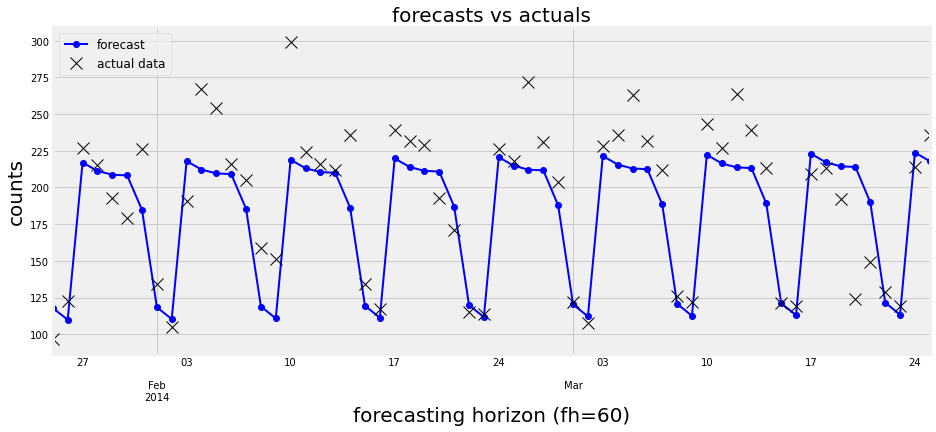

In [24]:
forecasts_fh60['holtwinters'].y_pred.plot(label='forecast', color='blue', marker='o', linewidth=2)
actual_data['count'].plot(label='actual data', color='black', marker='x', markersize=12, linestyle='None')
plt.title('forecasts vs actuals', size=20)
plt.xlabel('forecasting horizon (fh=60)', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(14, 6)
plt.legend(loc=2, prop={'size': 12})
plt.show()

## Rolling 1-day forecasting (fh=1)

In [25]:
performance_summary_fh_1 = pd.DataFrame()

for model, df in forecasts_fh_1.items():
    forecasts_fh_1[model].rename(columns={'fcst': 'y_pred'}, inplace=True)
    errors = fcst_errors(actual_data['count'], df.y_pred, model)
    performance_summary_fh_1 = performance_summary_fh_1.append(errors, ignore_index=True)
    
performance_summary_fh_1.set_index('Model',inplace=True)
performance_summary_fh_1.sort_values(by='MAE')

,MAE,MAPE,RMSE
Model,,,
SARIMA,17.547,9.673,25.091
holtwinters,19.070,10.448,25.490
enet,27.012,14.737,34.771
Prophet,27.812,16.254,34.996
gbr,28.820,15.905,38.383
knn,46.071,22.537,54.774


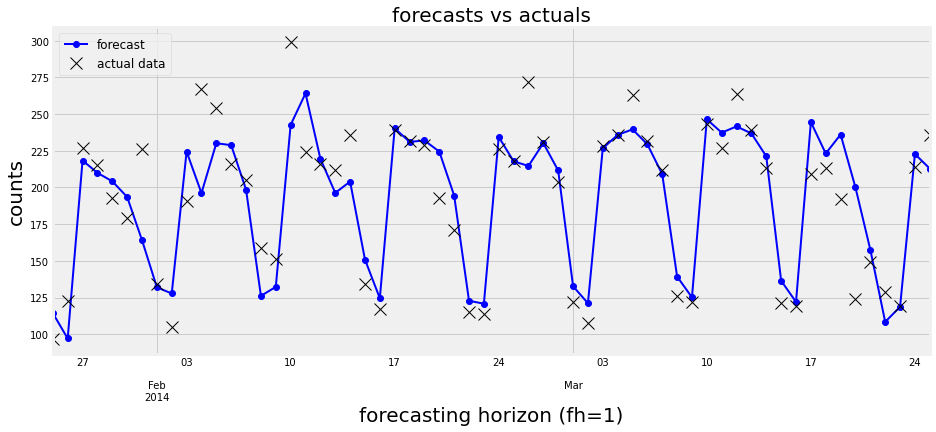

In [26]:
forecasts_fh_1['SARIMA'].y_pred.plot(label='forecast', color='blue', marker='o', linewidth=2)
actual_data['count'].plot(label='actual data', color='black', marker='x', markersize=12, linestyle='None')
plt.title('forecasts vs actuals', size=20)
plt.xlabel('forecasting horizon (fh=1)', size=20)
plt.ylabel('counts', size = 20)
plt.gcf().set_size_inches(14, 6)
plt.legend(loc=2, prop={'size': 12})
plt.show()